In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

/tmp/ipython-input-1476976764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', ax=axes[0], palette='coolwarm')
/tmp/ipython-input-1476976764.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', ax=axes[1], palette='Set2')
/tmp/ipython-input-1476976764.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', ax=axes[3], palette='pastel')
/tmp/ipython-input-1476976764.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

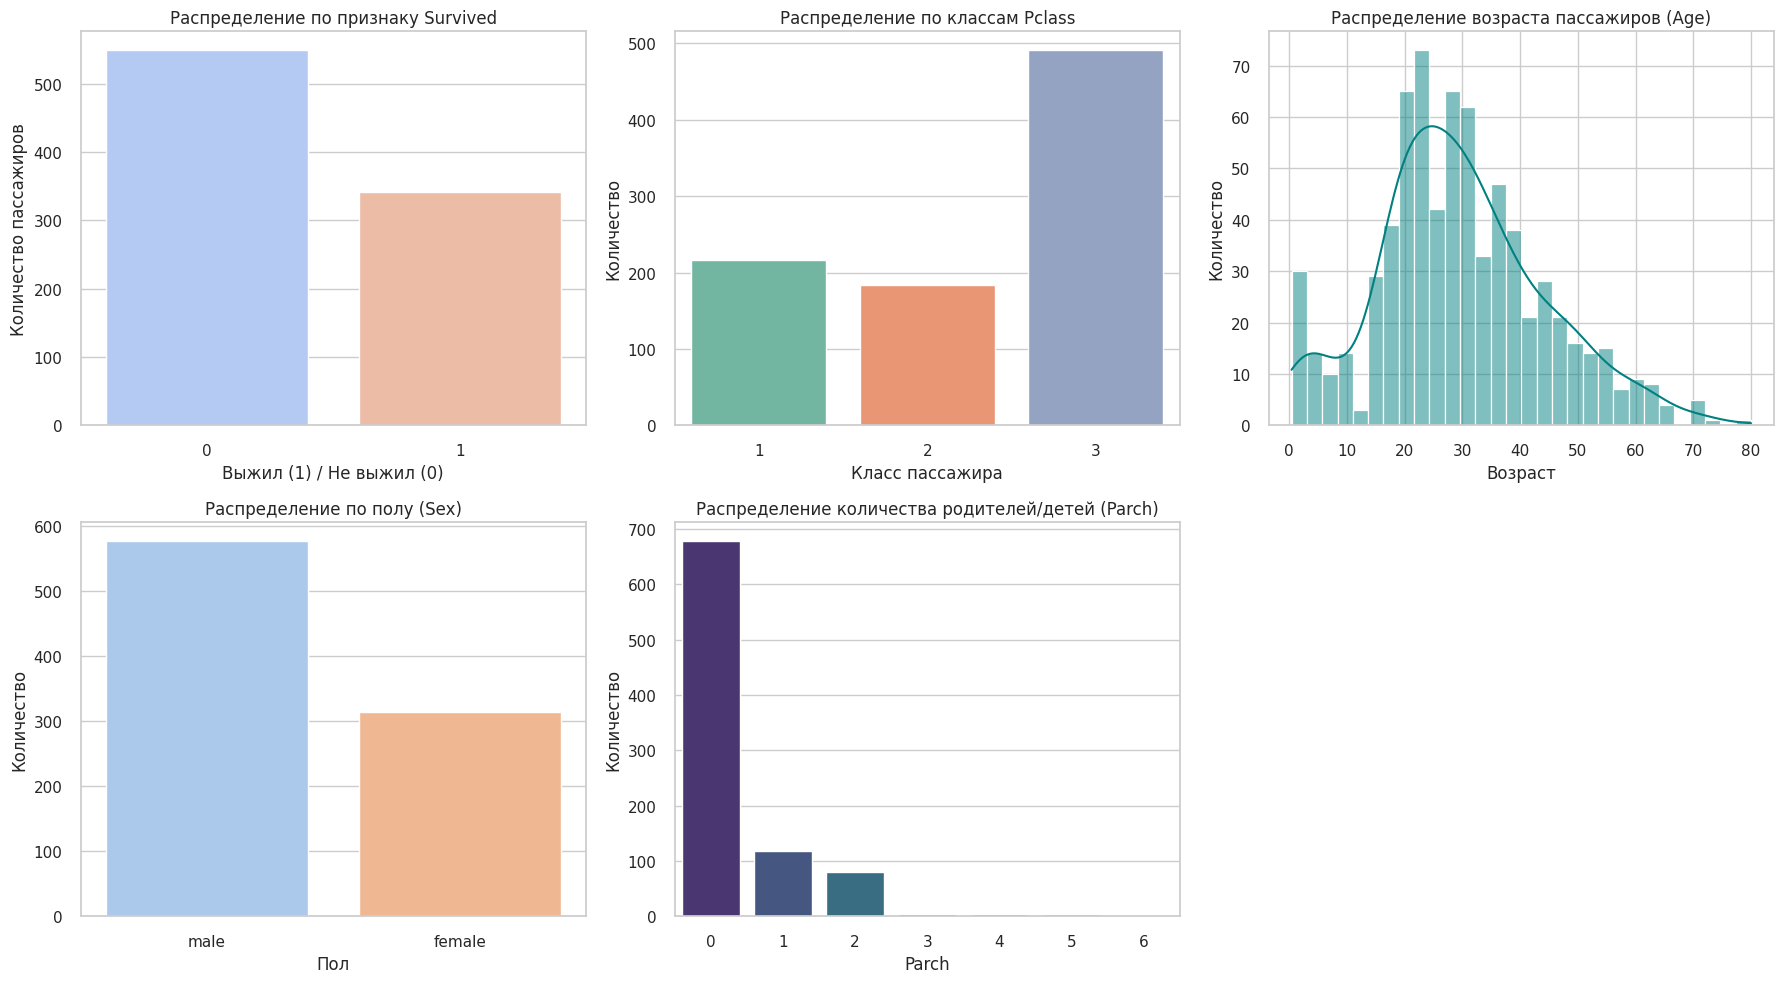

In [5]:
df = pd.read_csv('/content/train.csv')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

sns.countplot(data=df, x='Survived', ax=axes[0], palette='coolwarm')
axes[0].set_title('Распределение по признаку Survived')
axes[0].set_xlabel('Выжил (1) / Не выжил (0)')
axes[0].set_ylabel('Количество пассажиров')

sns.countplot(data=df, x='Pclass', ax=axes[1], palette='Set2')
axes[1].set_title('Распределение по классам Pclass')
axes[1].set_xlabel('Класс пассажира')
axes[1].set_ylabel('Количество')

sns.histplot(data=df, x='Age', kde=True, bins=30, color='teal', ax=axes[2])
axes[2].set_title('Распределение возраста пассажиров (Age)')
axes[2].set_xlabel('Возраст')
axes[2].set_ylabel('Количество')

sns.countplot(data=df, x='Sex', ax=axes[3], palette='pastel')
axes[3].set_title('Распределение по полу (Sex)')
axes[3].set_xlabel('Пол')
axes[3].set_ylabel('Количество')

sns.countplot(data=df, x='Parch', ax=axes[4], palette='viridis')
axes[4].set_title('Распределение количества родителей/детей (Parch)')
axes[4].set_xlabel('Parch')
axes[4].set_ylabel('Количество')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

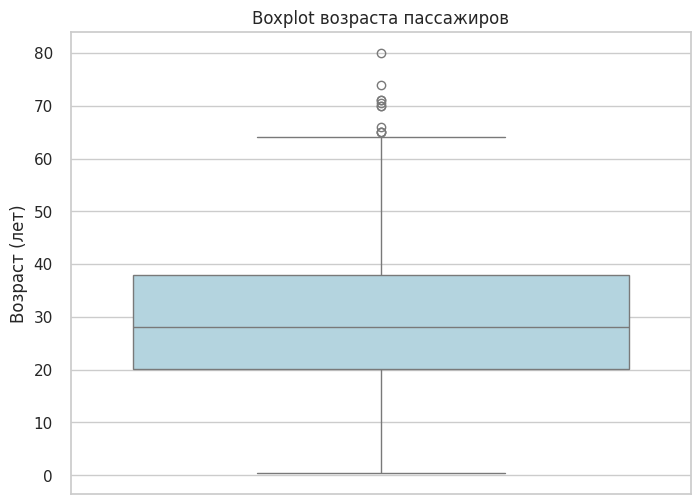

In [6]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='Age', color='lightblue')
plt.title('Boxplot возраста пассажиров')
plt.ylabel('Возраст (лет)')
plt.show()

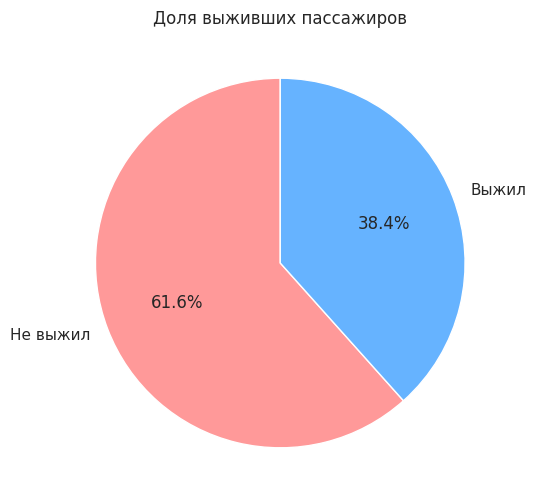

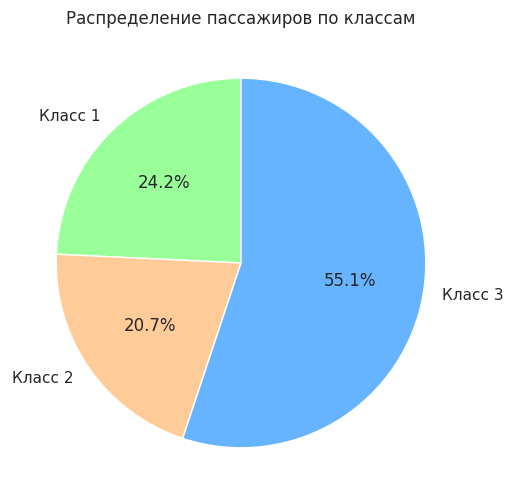

In [7]:
plt.figure(figsize=(6,6))
surv_counts = df['Survived'].value_counts()
plt.pie(
    surv_counts,
    labels=['Не выжил', 'Выжил'],
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff'],
    startangle=90
)
plt.title('Доля выживших пассажиров')
plt.show()

plt.figure(figsize=(6,6))
pclass_counts = df['Pclass'].value_counts().sort_index()
plt.pie(
    pclass_counts,
    labels=[f'Класс {cls}' for cls in pclass_counts.index],
    autopct='%1.1f%%',
    colors=['#99ff99','#ffcc99','#66b3ff'],
    startangle=90
)
plt.title('Распределение пассажиров по классам')
plt.show()

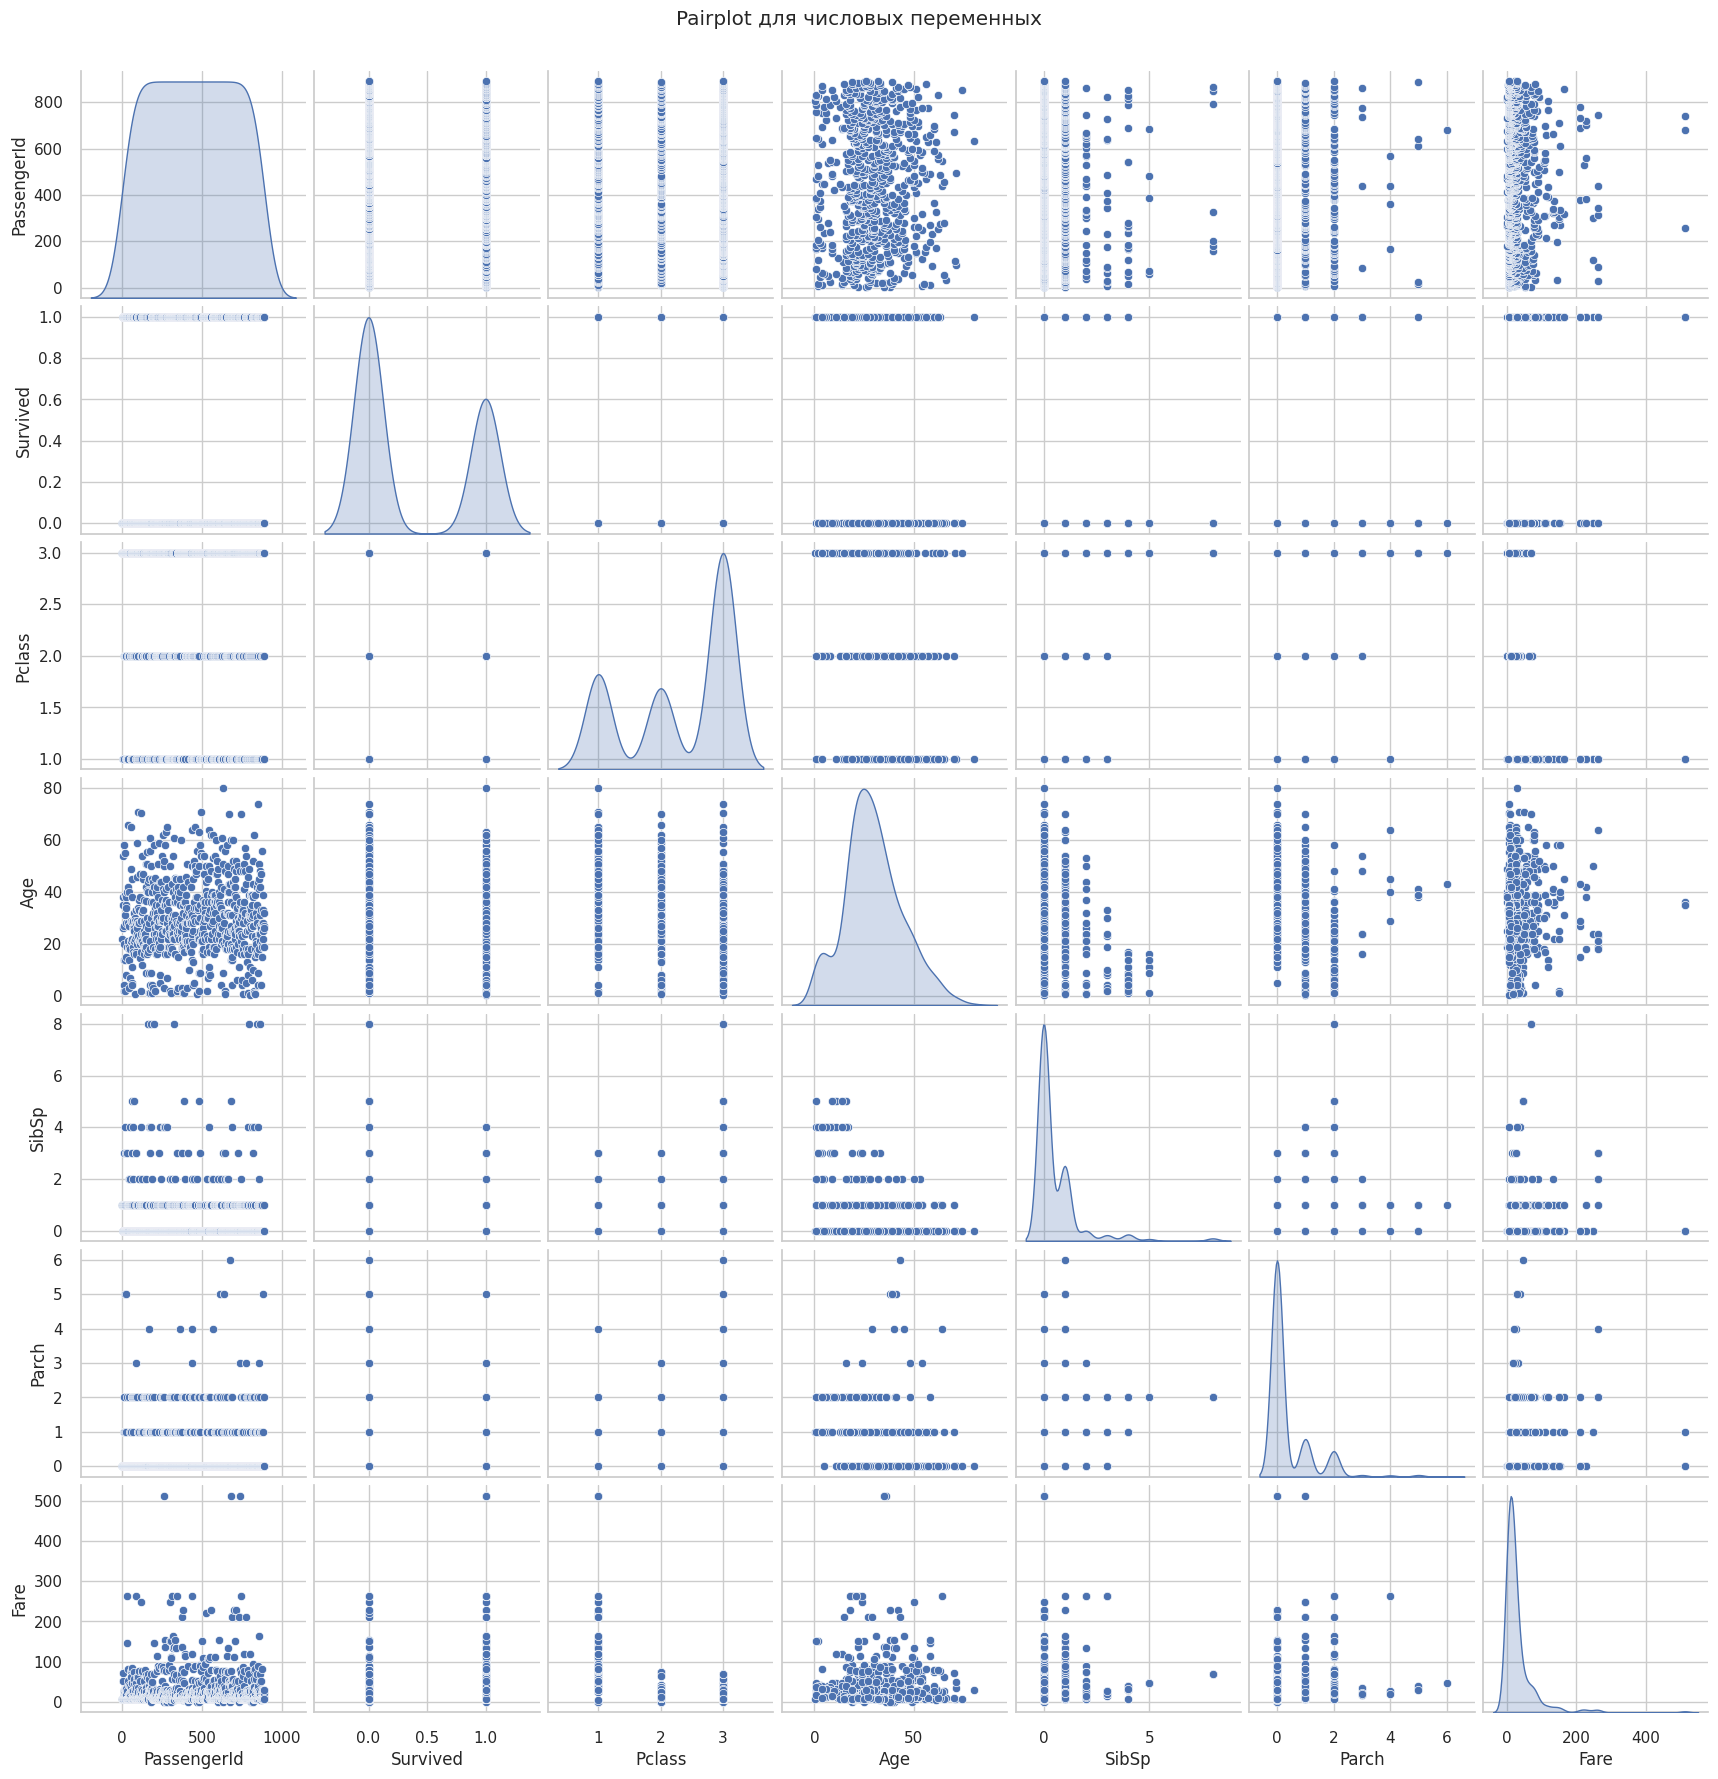

In [8]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.pairplot(df[numeric_cols], diag_kind='kde')
plt.suptitle('Pairplot для числовых переменных', y=1.02)
plt.show()

In [9]:
fig = px.sunburst(
    df,
    path=['Pclass', 'Sex'],
    title='Иерархическая визуализация (Sunburst): Класс → Пол',
    color='Pclass',
    color_continuous_scale='RdBu',
    width=600,
    height=600
)
fig.show()